In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [2]:
import pandas as pd
import os

# Define the dataset location
DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

# Load the CSV files
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

# Display basic information
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain data:")
display(train_df.head())

print("\nTest data:")
display(test_df.head())

print("\nSample submission:")
display(sample_submission.head())

Train shape: (769, 2)
Test shape: (216, 2)

Train data:


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0



Test data:


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1



Sample submission:


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1


Grammar score statistics:


count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


Score counts:


label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64

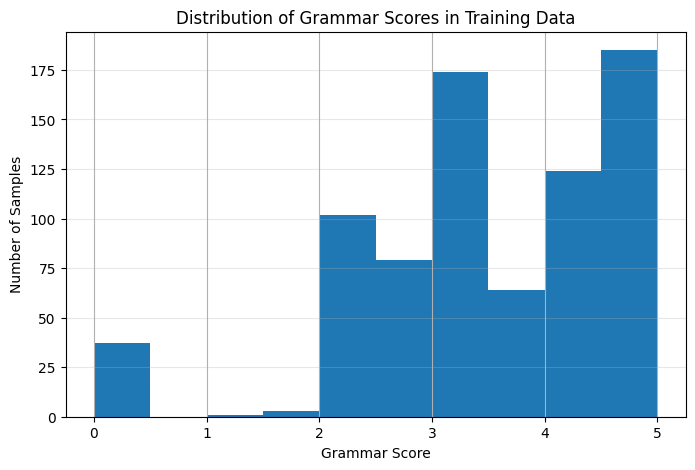

In [3]:
import matplotlib.pyplot as plt

# Look at the distribution of grammar scores
print("Grammar score statistics:")
display(train_df["label"].describe())

# Count each score
print("\nScore counts:")
display(train_df["label"].value_counts().sort_index())

# Plot the distribution
plt.figure(figsize=(8, 5))
train_df["label"].hist(bins=10)
plt.xlabel("Grammar Score")
plt.ylabel("Number of Samples")
plt.title("Distribution of Grammar Scores in Training Data")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [2]:
import pandas as pd
import os

# Dataset location
DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

# Load the datasets
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(
    os.path.join(DATA_DIR, "sample_submission.csv")
)

# Confirm everything loaded correctly
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)


In [3]:
import os
import wave

# Pick the first training audio file
sample_filename = train_df.iloc[0]["filename"]
sample_path = os.path.join(DATA_DIR, "train", sample_filename)

print("Testing audio file:")
print(sample_path)

# Read basic WAV information
with wave.open(sample_path, "rb") as wav:
    channels = wav.getnchannels()
    sample_rate = wav.getframerate()
    sample_width = wav.getsampwidth()
    num_frames = wav.getnframes()
    duration = num_frames / sample_rate

print("\nAudio information:")
print("Channels:", channels)
print("Sample rate:", sample_rate, "Hz")
print("Sample width:", sample_width, "bytes")
print("Number of frames:", num_frames)
print("Duration:", round(duration, 2), "seconds")

Testing audio file:
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train/audio_192.wav

Audio information:
Channels: 1
Sample rate: 16000 Hz
Sample width: 2 bytes
Number of frames: 968134
Duration: 60.51 seconds


In [4]:
import librosa

print("librosa version:", librosa.__version__)

librosa version: 0.11.0


In [5]:
import numpy as np
import pandas as pd
import librosa
import os
from tqdm.auto import tqdm

def extract_basic_features(file_path):
    """
    Extract simple acoustic features from one audio file.
    """
    y, sr = librosa.load(file_path, sr=16000, mono=True)

    # 1. Duration
    duration = len(y) / sr

    # 2. Root Mean Square (RMS) energy
    rms = librosa.feature.rms(y=y)[0]

    # 3. Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)[0]

    features = {
        "duration": duration,
        "rms_mean": np.mean(rms),
        "rms_std": np.std(rms),
        "zcr_mean": np.mean(zcr),
        "zcr_std": np.std(zcr),
    }

    return features


# Extract features for every training file
feature_rows = []

for filename in tqdm(train_df["filename"], desc="Extracting audio features"):
    file_path = os.path.join(DATA_DIR, "train", filename)

    try:
        features = extract_basic_features(file_path)
        features["filename"] = filename
        feature_rows.append(features)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

# Convert to DataFrame
features_df = pd.DataFrame(feature_rows)

# Add the grammar labels
features_df = features_df.merge(
    train_df[["filename", "label"]],
    on="filename",
    how="left"
)

print("\nFeature dataset shape:", features_df.shape)
display(features_df.head())

Extracting audio features:   0%|          | 0/769 [00:00<?, ?it/s]


Feature dataset shape: (769, 7)


,duration,rms_mean,rms_std,zcr_mean,zcr_std,filename,label
0,60.508375,0.031786,0.038404,0.084768,0.053518,audio_192.wav,3.0
1,60.074688,0.068651,0.055423,0.142977,0.127519,audio_436.wav,3.0
2,60.074688,0.054421,0.051533,0.146870,0.129777,audio_447.wav,3.5
3,45.060000,0.013778,0.012183,0.059477,0.036870,audio_126.wav,2.0
4,45.300000,0.009330,0.008970,0.169988,0.128430,audio_61.wav,2.0


In [6]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Features and target
feature_columns = [
    "duration",
    "rms_mean",
    "rms_std",
    "zcr_mean",
    "zcr_std"
]

X = features_df[feature_columns]
y = features_df["label"]

# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Simple baseline model
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Get out-of-fold predictions
predictions = cross_val_predict(
    model,
    X,
    y,
    cv=kf,
    n_jobs=-1
)

# Evaluation metrics
rmse = np.sqrt(mean_squared_error(y, predictions))
pearson = pearsonr(y, predictions)[0]

print("Baseline Results")
print("----------------")
print(f"RMSE: {rmse:.4f}")
print(f"Pearson Correlation: {pearson:.4f}")

Baseline Results
----------------
RMSE: 0.9058
Pearson Correlation: 0.6825


In [7]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Transformers: 5.16.1
GPU available: False


In [8]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
GPU available: False


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [2]:
print("train_df exists:", "train_df" in globals())
print("test_df exists:", "test_df" in globals())
print("features_df exists:", "features_df" in globals())
print("DATA_DIR:", DATA_DIR)

train_df exists: False
test_df exists: False
features_df exists: False


NameError: name 'DATA_DIR' is not defined

In [3]:
import pandas as pd
import os

# Dataset location
DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"

# Load CSV files
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
sample_submission = pd.read_csv(
    os.path.join(DATA_DIR, "sample_submission.csv")
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_submission.shape)

Train shape: (769, 2)
Test shape: (216, 2)
Sample submission shape: (204, 2)


In [4]:
from transformers import AutoFeatureExtractor, AutoModel
import torch

MODEL_NAME = "facebook/wav2vec2-base"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print("Loading:", MODEL_NAME)

feature_extractor = AutoFeatureExtractor.from_pretrained(MODEL_NAME)
speech_model = AutoModel.from_pretrained(MODEL_NAME)

speech_model = speech_model.to(device)
speech_model.eval()

print("Model loaded successfully!")

Using device: cuda
Loading: facebook/wav2vec2-base


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.84k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  380MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  380MB            

model.safetensors: downloading bytes:           |  0.00B            

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!


In [5]:
import librosa
import torch
import numpy as np
import os

# Pick one training audio file
sample_filename = train_df.iloc[0]["filename"]
sample_path = os.path.join(DATA_DIR, "train", sample_filename)

print("Testing file:", sample_filename)

# Load audio at the model's required sampling rate
audio, sr = librosa.load(
    sample_path,
    sr=16000,
    mono=True
)

print("Audio shape:", audio.shape)
print("Sample rate:", sr)
print("Duration:", len(audio) / sr, "seconds")

# Convert audio into model input
inputs = feature_extractor(
    audio,
    sampling_rate=16000,
    return_tensors="pt"
)

input_values = inputs.input_values.to(device)

# Run Wav2Vec2
with torch.inference_mode():
    outputs = speech_model(input_values=input_values)

# Average all time steps into one fixed-size embedding
embedding = outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy()

print("Embedding shape:", embedding.shape)
print("First 5 values:", embedding[:5])

Testing file: audio_192.wav
Audio shape: (968134,)
Sample rate: 16000
Duration: 60.508375 seconds
Embedding shape: (768,)
First 5 values: [-0.15940322 -0.06219045  0.06013479  0.31210983  0.0989903 ]


In [6]:
from tqdm.auto import tqdm
import numpy as np
import librosa
import torch
import os

def extract_wav2vec_embedding(file_path):
    # Load audio
    audio, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    # Prepare model input
    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_values = inputs.input_values.to(device)

    # Extract embedding
    with torch.inference_mode():
        outputs = speech_model(input_values=input_values)

    # Mean-pool across time
    embedding = (
        outputs.last_hidden_state
        .mean(dim=1)
        .squeeze(0)
        .cpu()
        .numpy()
    )

    return embedding


# Extract embeddings for all training files
train_embeddings = []

for filename in tqdm(
    train_df["filename"],
    desc="Extracting training embeddings"
):
    file_path = os.path.join(
        DATA_DIR,
        "train",
        filename
    )

    embedding = extract_wav2vec_embedding(file_path)
    train_embeddings.append(embedding)

train_embeddings = np.vstack(train_embeddings)

print("\nTraining embeddings shape:", train_embeddings.shape)

Extracting training embeddings:   0%|          | 0/769 [00:00<?, ?it/s]


Training embeddings shape: (769, 768)


In [7]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

# Features and target
X = train_embeddings
y = train_df["label"].values

# 5-fold cross-validation
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Standardization + Ridge regression
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10.0))
])

# Out-of-fold predictions
ridge_predictions = cross_val_predict(
    ridge_model,
    X,
    y,
    cv=kf,
    n_jobs=-1
)

# Evaluation
ridge_rmse = np.sqrt(
    mean_squared_error(y, ridge_predictions)
)

ridge_pearson = pearsonr(
    y,
    ridge_predictions
)[0]

print("Wav2Vec2 + Ridge Results")
print("------------------------")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"Pearson Correlation: {ridge_pearson:.4f}")

Wav2Vec2 + Ridge Results
------------------------
RMSE: 0.7418
Pearson Correlation: 0.8102


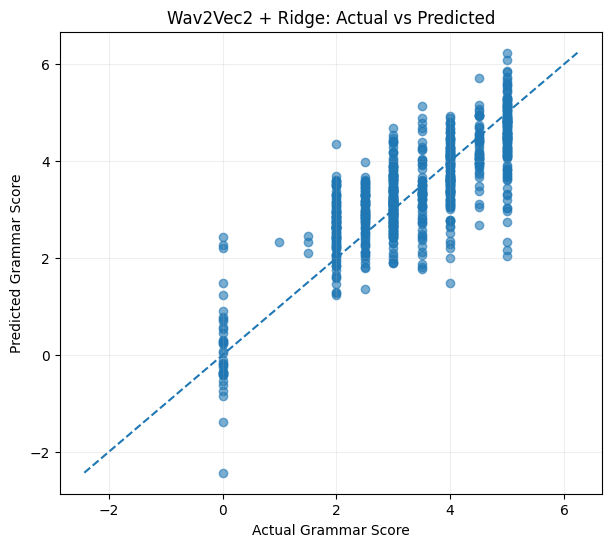

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y,
    ridge_predictions,
    alpha=0.6
)

# Perfect prediction line
min_score = min(y.min(), ridge_predictions.min())
max_score = max(y.max(), ridge_predictions.max())

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--"
)

plt.xlabel("Actual Grammar Score")
plt.ylabel("Predicted Grammar Score")
plt.title("Wav2Vec2 + Ridge: Actual vs Predicted")

plt.grid(alpha=0.2)
plt.show()

In [9]:
print("Prediction range:")
print(f"Minimum: {ridge_predictions.min():.3f}")
print(f"Maximum: {ridge_predictions.max():.3f}")
print(f"Mean:    {ridge_predictions.mean():.3f}")

print("\nTarget range:")
print(f"Minimum: {y.min():.3f}")
print(f"Maximum: {y.max():.3f}")
print(f"Mean:    {y.mean():.3f}")

Prediction range:
Minimum: -2.430
Maximum: 6.238
Mean:    3.339

Target range:
Minimum: 0.000
Maximum: 5.000
Mean:    3.313


In [10]:
# Clip predictions to the valid grammar-score range
ridge_predictions_clipped = np.clip(
    ridge_predictions,
    0,
    5
)

clipped_rmse = np.sqrt(
    mean_squared_error(y, ridge_predictions_clipped)
)

clipped_pearson = pearsonr(
    y,
    ridge_predictions_clipped
)[0]

print("Wav2Vec2 + Ridge — Clipped Predictions")
print("---------------------------------------")
print(f"RMSE: {clipped_rmse:.4f}")
print(f"Pearson Correlation: {clipped_pearson:.4f}")

print("\nPrediction range after clipping:")
print(f"Minimum: {ridge_predictions_clipped.min():.3f}")
print(f"Maximum: {ridge_predictions_clipped.max():.3f}")

Wav2Vec2 + Ridge — Clipped Predictions
---------------------------------------
RMSE: 0.7232
Pearson Correlation: 0.8137

Prediction range after clipping:
Minimum: 0.000
Maximum: 5.000


In [11]:
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr
import numpy as np

alphas = [0.1, 1.0, 10.0, 30.0, 100.0]

results = []

for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    predictions = cross_val_predict(
        model,
        X,
        y,
        cv=kf,
        n_jobs=-1
    )

    # Keep predictions inside the valid 0–5 score range
    predictions_clipped = np.clip(
        predictions,
        0,
        5
    )

    rmse = np.sqrt(
        mean_squared_error(y, predictions_clipped)
    )

    pearson = pearsonr(
        y,
        predictions_clipped
    )[0]

    results.append({
        "alpha": alpha,
        "RMSE": rmse,
        "Pearson": pearson
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values("RMSE")
)

,alpha,RMSE,Pearson
4,100.0,0.695125,0.827668
3,30.0,0.697680,0.826384
2,10.0,0.723194,0.813743
1,1.0,0.864673,0.746517
0,0.1,1.142234,0.612265


In [12]:
print("Test rows:", len(test_df))
print("Sample submission rows:", len(sample_submission))

print(
    "Test files also in sample submission:",
    test_df["filename"].isin(sample_submission["filename"]).sum()
)

print(
    "Sample submission files also in test:",
    sample_submission["filename"].isin(test_df["filename"]).sum()
)

test_only = sorted(
    set(test_df["filename"]) -
    set(sample_submission["filename"])
)

submission_only = sorted(
    set(sample_submission["filename"]) -
    set(test_df["filename"])
)

print("\nFiles in test.csv but NOT sample_submission.csv:")
print(test_only)
print("Count:", len(test_only))

print("\nFiles in sample_submission.csv but NOT test.csv:")
print(submission_only)
print("Count:", len(submission_only))

Test rows: 216
Sample submission rows: 204
Test files also in sample submission: 25
Sample submission files also in test: 25

Files in test.csv but NOT sample_submission.csv:
['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav', 'audio_102.wav', 'audio_103.wav', 'audio_104.wav', 'audio_105.wav', 'audio_106.wav', 'audio_107.wav', 'audio_109.wav', 'audio_11.wav', 'audio_110.wav', 'audio_111.wav', 'audio_112.wav', 'audio_113.wav', 'audio_114.wav', 'audio_115.wav', 'audio_116.wav', 'audio_118.wav', 'audio_119.wav', 'audio_12.wav', 'audio_120.wav', 'audio_121.wav', 'audio_122.wav', 'audio_123.wav', 'audio_124.wav', 'audio_125.wav', 'audio_126.wav', 'audio_127.wav', 'audio_129.wav', 'audio_131.wav', 'audio_132.wav', 'audio_133.wav', 'audio_134.wav', 'audio_135.wav', 'audio_136.wav', 'audio_137.wav', 'audio_138.wav', 'audio_139.wav', 'audio_140.wav', 'audio_141.wav', 'audio_142.wav', 'audio_143.wav', 'audio_144.wav', 'audio_145.wav', 'audio_146.wav', 'audio_147.wav'

In [13]:
import os

train_files = set(train_df["filename"])
test_files = set(test_df["filename"])
submission_files = set(sample_submission["filename"])

all_audio_files = set()

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.endswith(".wav"):
            all_audio_files.add(file)

print("Total .wav files found:", len(all_audio_files))
print("Train CSV files:", len(train_files))
print("Test CSV files:", len(test_files))
print("Sample submission files:", len(submission_files))

print("\n--- Overlaps ---")
print("Train ∩ Test:", len(train_files & test_files))
print("Train ∩ Submission:", len(train_files & submission_files))
print("Test ∩ Submission:", len(test_files & submission_files))

print("\n--- Audio files not referenced by train.csv ---")
print("Count:", len(all_audio_files - train_files))

print("\n--- Audio files referenced by neither train nor test ---")
print("Count:", len(all_audio_files - train_files - test_files))

Total .wav files found: 773
Train CSV files: 769
Test CSV files: 216
Sample submission files: 204

--- Overlaps ---
Train ∩ Test: 212
Train ∩ Submission: 105
Test ∩ Submission: 25

--- Audio files not referenced by train.csv ---
Count: 4

--- Audio files referenced by neither train nor test ---
Count: 0


In [14]:
id("inspect-splits")

# Files that physically exist but are not in train.csv
unlabeled_audio = sorted(all_audio_files - train_files)

print("Audio files not present in train.csv:")
for f in unlabeled_audio:
    print(" ", f)

print("\nCount:", len(unlabeled_audio))

print("\nSample submission filenames:")
print(sample_submission["filename"].tolist())

print("\nTest filenames that ARE in sample submission:")
print(
    sorted(
        set(test_df["filename"]) & set(sample_submission["filename"])
    )
)

Audio files not present in train.csv:
  audio_195.wav
  audio_201.wav
  audio_202.wav
  audio_69.wav

Count: 4

Sample submission filenames:
['audio_804.wav', 'audio_1028.wav', 'audio_865.wav', 'audio_774.wav', 'audio_1138.wav', 'audio_278.wav', 'audio_1212.wav', 'audio_178.wav', 'audio_542.wav', 'audio_248.wav', 'audio_872.wav', 'audio_954.wav', 'audio_853.wav', 'audio_171.wav', 'audio_922.wav', 'audio_915.wav', 'audio_1220.wav', 'audio_1225.wav', 'audio_903.wav', 'audio_748.wav', 'audio_284.wav', 'audio_200.wav', 'audio_1255.wav', 'audio_1246.wav', 'audio_1102.wav', 'audio_1300.wav', 'audio_80.wav', 'audio_1041.wav', 'audio_256.wav', 'audio_328.wav', 'audio_301.wav', 'audio_938.wav', 'audio_1055.wav', 'audio_664.wav', 'audio_89.wav', 'audio_407.wav', 'audio_1025.wav', 'audio_72.wav', 'audio_1316.wav', 'audio_661.wav', 'audio_822.wav', 'audio_956.wav', 'audio_1329.wav', 'audio_1218.wav', 'audio_1286.wav', 'audio_1166.wav', 'audio_1231.wav', 'audio_501.wav', 'audio_188.wav', 'audio_746

In [15]:
print("TRAIN CSV")
display(train_df.head(10))
print("\nColumns:", train_df.columns.tolist())

print("\nTEST CSV")
display(test_df.head(10))
print("\nColumns:", test_df.columns.tolist())

print("\nSAMPLE SUBMISSION")
display(sample_submission.head(10))
print("\nColumns:", sample_submission.columns.tolist())

TRAIN CSV


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0
5,audio_639.wav,2.5
6,audio_703.wav,2.0
7,audio_509.wav,3.0
8,audio_672.wav,4.0
9,audio_344.wav,4.0



Columns: ['filename', 'label']

TEST CSV


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1
5,audio_161.wav,-1
6,audio_215.wav,-1
7,audio_213.wav,-1
8,audio_11.wav,-1
9,audio_155.wav,-1



Columns: ['filename', 'label']

SAMPLE SUBMISSION


,filename,label
0,audio_804.wav,-1
1,audio_1028.wav,-1
2,audio_865.wav,-1
3,audio_774.wav,-1
4,audio_1138.wav,-1
5,audio_278.wav,-1
6,audio_1212.wav,-1
7,audio_178.wav,-1
8,audio_542.wav,-1
9,audio_248.wav,-1



Columns: ['filename', 'label']


In [16]:
unseen_test_files = sorted(
    set(test_df["filename"]) - set(train_df["filename"])
)

print("Test files NOT present in training data:")
for f in unseen_test_files:
    print(f)

print("\nCount:", len(unseen_test_files))

Test files NOT present in training data:
audio_195.wav
audio_201.wav
audio_202.wav
audio_69.wav

Count: 4


In [17]:
from tqdm.auto import tqdm
import numpy as np
import librosa
import torch
import os

def extract_wav2vec_embedding(file_path):
    audio, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    inputs = feature_extractor(
        audio,
        sampling_rate=16000,
        return_tensors="pt"
    )

    input_values = inputs.input_values.to(device)

    with torch.inference_mode():
        outputs = speech_model(
            input_values=input_values
        )

    embedding = (
        outputs.last_hidden_state
        .mean(dim=1)
        .squeeze(0)
        .cpu()
        .numpy()
    )

    return embedding


test_embeddings = []

for filename in tqdm(
    test_df["filename"],
    desc="Extracting test embeddings"
):
    file_path = os.path.join(
        DATA_DIR,
        "test",
        filename
    )

    embedding = extract_wav2vec_embedding(file_path)
    test_embeddings.append(embedding)

test_embeddings = np.vstack(test_embeddings)

print("\nTest embeddings shape:", test_embeddings.shape)

Extracting test embeddings:   0%|          | 0/216 [00:00<?, ?it/s]


Test embeddings shape: (216, 768)


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# Final model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=100.0))
])

# Train on ALL available labeled training data
final_model.fit(
    train_embeddings,
    train_df["label"].values
)

# Training predictions
train_pred = final_model.predict(train_embeddings)

# Keep predictions within the valid score range
train_pred_clipped = np.clip(train_pred, 0, 5)

# Mandatory training RMSE
train_rmse = np.sqrt(
    mean_squared_error(
        train_df["label"].values,
        train_pred_clipped
    )
)

# Test predictions
test_pred = final_model.predict(test_embeddings)

# Keep final predictions within 0-5
test_pred_clipped = np.clip(test_pred, 0, 5)

print("Final Model Results")
print("-------------------")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Test prediction min: {test_pred_clipped.min():.4f}")
print(f"Test prediction max: {test_pred_clipped.max():.4f}")
print(f"Test prediction mean: {test_pred_clipped.mean():.4f}")

Final Model Results
-------------------
Training RMSE: 0.4927
Test prediction min: 1.4872
Test prediction max: 5.0000
Test prediction mean: 3.2873


In [19]:
import pandas as pd
import numpy as np

# Create submission using the exact order of test.csv
submission = pd.DataFrame({
    "filename": test_df["filename"],
    "label": np.round(test_pred_clipped, 4)
})

# Safety checks
assert len(submission) == 216
assert submission["filename"].tolist() == test_df["filename"].tolist()
assert submission["label"].between(0, 5).all()
assert submission["filename"].is_unique

# Save submission
submission.to_csv("submission.csv", index=False)

print("Submission created successfully!")
print("Shape:", submission.shape)
print("\nFirst 10 rows:")
display(submission.head(10))

print("\nLabel statistics:")
print(submission["label"].describe())

Submission created successfully!
Shape: (216, 2)

First 10 rows:


,filename,label
0,audio_128.wav,3.1307
1,audio_156.wav,3.8072
2,audio_19.wav,4.2879
3,audio_108.wav,2.3710
4,audio_206.wav,2.7312
5,audio_161.wav,2.0937
6,audio_215.wav,2.8283
7,audio_213.wav,2.1966
8,audio_11.wav,3.1685
9,audio_155.wav,3.1909



Label statistics:
count    216.000000
mean       3.287297
std        0.689308
min        1.487200
25%        2.818275
50%        3.226450
75%        3.676400
max        5.000000
Name: label, dtype: float64


In [20]:
submission.to_csv("submission.csv", index=False)